In [ ]:
import matplotlib.pyplot as plt
import torch
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import seaborn
import cv2
import os
from time import time
from torch import nn
from tqdm import tqdm
from torch.utils.data import Dataset
from PIL import Image
from torchvision.transforms import functional as TF
import torch.nn.functional as F
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Итак, часть вторая.

#Датасет. Обычный и для Triplet Loss.

Мы предусмотрительно подготовили все в первой части, осталось только подгрузить и проверить, не потерялось ли что-нибудь по дороге.

In [ ]:
!unzip -q /content/drive/MyDrive/Share/Face_Recognition/aligned_classifier_train_500.zip -d /content/aligned_classifier_train_500
train_dir = "/content/aligned_classifier_train_500"
!unzip -q /content/drive/MyDrive/Share/Face_Recognition/aligned_classifier_val_500.zip -d /content/aligned_classifier_val_500
val_dir = "/content/aligned_classifier_val_500"

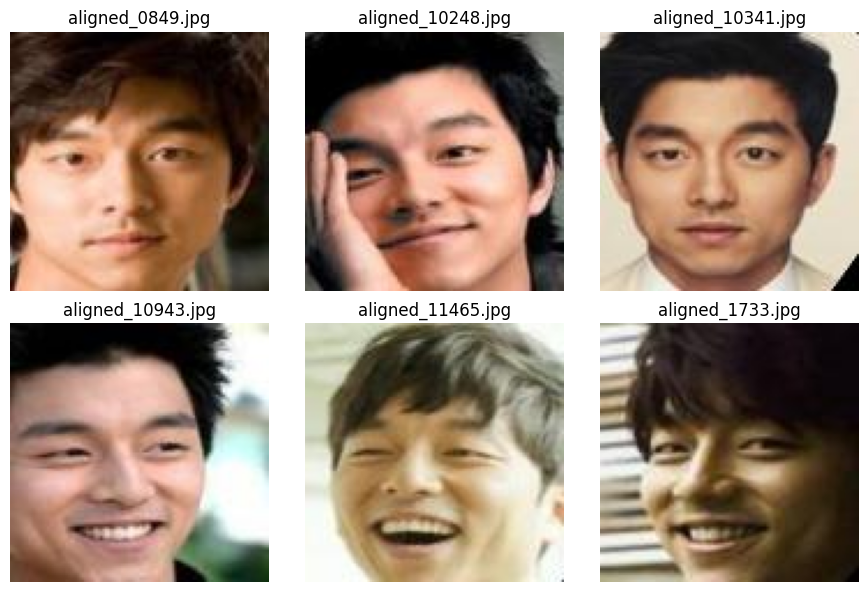

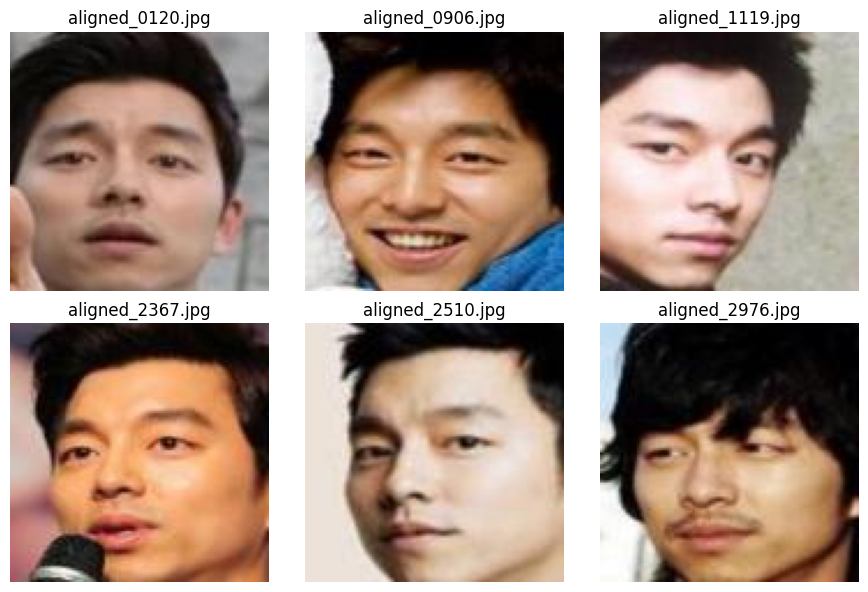

In [ ]:
def show_aligned_faces(folder_path, n=12, cols=4):
    image_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    image_files = image_files[:n]

    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    for ax, fname in zip(axes.flatten(), image_files):
        img = Image.open(os.path.join(folder_path, fname))
        ax.imshow(img)
        ax.set_title(fname)
        ax.axis('off')

    # Отключаем лишние оси
    for ax in axes.flatten()[len(image_files):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Вызов
show_aligned_faces("/content/aligned_classifier_train_500/10060", n=6, cols=3)
show_aligned_faces("/content/aligned_classifier_val_500/10060", n=6, cols=3)


Ура, все на месте.

Теперь не менее предусмотрительно создадим датасет, где каждое возвращаемое значение - это тройка изображений: anchor, positive, negative.  

Anchor берётся по текущему индексу.  
Positive - случайное другое изображение той же identity.  
Negative - случайное изображение из другой identity.  

Таким образом мы формируем триплеты, на которых в последствии будет обучаться Triplet Loss.

In [ ]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
import random
from collections import defaultdict

class TripletDatasetFromFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.image_paths = []
        self.labels = []

        self.label_to_indices = defaultdict(list)
        for label_folder in sorted(self.root_dir.iterdir()):
            if not label_folder.is_dir():
                continue
            label = label_folder.name
            for img_path in label_folder.glob("*.*"):
                self.image_paths.append(str(img_path))
                self.labels.append(label)
                self.label_to_indices[label].append(len(self.image_paths) - 1)

        self.labels_set = sorted(set(self.labels))

    def __getitem__(self, index):
        anchor_path = self.image_paths[index]
        anchor_label = self.labels[index]

        positive_index = random.choice(self.label_to_indices[anchor_label])
        while positive_index == index:
            positive_index = random.choice(self.label_to_indices[anchor_label])

        negative_label = random.choice([l for l in self.labels_set if l != anchor_label])
        negative_index = random.choice(self.label_to_indices[negative_label])

        a_img = Image.open(self.image_paths[index]).convert("RGB")
        p_img = Image.open(self.image_paths[positive_index]).convert("RGB")
        n_img = Image.open(self.image_paths[negative_index]).convert("RGB")

        if self.transform:
            a_img = self.transform(a_img)
            p_img = self.transform(p_img)
            n_img = self.transform(n_img)

        return a_img, p_img, n_img

    def __len__(self):
        return len(self.image_paths)


Сначала создаем DataLoader'ы для моделей, не использующих Triplet Loss

Для обучающей выборки используем следующие аугментации:
- изменение яркости и контраста (ColorJitter),
- случайное горизонтальное отражение (RandomHorizontalFlip),
- случайное вращение (RandomRotation),
Это позволит повысить устойчивость модели к искажениям и не превратит обучение в бесконечный непродуктивный ад.

Для валидационной выборки применяем только базовые преобразования - изменение размера и преобразование в тензор.

Размер батча - 32.

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader


train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(root='/content/aligned_classifier_train_500', transform=train_transform)
val_dataset   = ImageFolder(root='/content/aligned_classifier_val_500', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

А теперь создаем Triplet Loss-ориентированные DataLoader'ы с минимальными трансформациями (Resize + ToTensor).  

Аугментации минимальны, так как нам не нужно, чтобы в результате аугментаций positive стал менее похожим на anchor, чем negative - это нарушит смысл лосса. К тому же, мы хотим, чтобы расстояния между эмбеддингами отражали реальные различия между лицами.

Остальное - как в предыдущем блоке.

In [ ]:
import torchvision.transforms as T
from torchvision.transforms import ToPILImage

train_transform_triplet = T.Compose([
    T.Resize((112, 112)),
    T.ToTensor()
])

train_triplet_ds = TripletDatasetFromFolder("/content/aligned_classifier_train_500", transform=train_transform_triplet)
val_triplet_ds = TripletDatasetFromFolder("/content/aligned_classifier_val_500", transform=train_transform_triplet)

train_loader_triplet = torch.utils.data.DataLoader(train_triplet_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader_triplet = torch.utils.data.DataLoader(val_triplet_ds, batch_size=32, shuffle=False, num_workers=4)


Все готово, можно начинать использование разных лоссов в погоне за accuracy > 0.7

##Обучение моделей

Далее мы создаем классификаторы лиц на базе предобученной **ResNet-50** и выбираем pretrained=True, чтобы использовать веса, обученные на ImageNet.

**Настройка обучения:**
- num_classes = 500 по числу identities в датасетах
- оптимизатор: Adam c начальным lr=1e-4
- ReduceLROnPlateau: снижает learning rate в два раза, если валидационный loss не улучшается три эпохи подряд

#CrossEntropy



$$L_{CE} = \frac{-1}{N}\sum_1^N \frac{e^{W_{y_i}^{T}x_i + b_{y_i}}}{\sum^n_{j=1}e^{W_j^Tx_i+b_j}},$$

- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети;  
- $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $b_j \in \mathbb{R^d}$ — j-ый элемент вектора байеса последнего слоя сети;
- $N$ — batch size;
- $n$ — количество классов.

Мы решаем задачу многоклассовой классификации лиц - каждому изображению сопоставляется один из 500 идентификаторов (identity).
Для этого мы берем ResNet50, модифицируем её последний слой, заменяя его на два полносвязных слоя (256 → 500), чтобы получить логиты - ненормализованные оценки принадлежности к каждому классу.

Затем применяется CrossEntropyLoss, которая сравнивает логиты с реальной меткой класса и настраивает веса модели, чтобы максимизировать вероятность правильного ответа.

Плюсы:  
- простая и хорошо изученная схема обучения.
- эффективна при наличии большого числа примеров на каждый класс.
- отлично подходит для задач с фиксированным числом классов.

Минусы:
- не учится сравнивать похожие изображения разных классов
- плохо переносится на новые, ранее не виденные лица (нет обобщения по сходству).

In [ ]:
import torch.nn as nn
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau

num_classes = len(train_dataset.classes)

model = models.resnet50(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
    threshold=1e-4, verbose=True
)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

In [ ]:
import copy

def train_classifier(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=10, device='cuda',
    save_path='best_checkpoint.pth'
):
    model.to(device)
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = train_loss / total
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        print(f"Train Loss: {epoch_train_loss:.4f}, Accuracy: {epoch_train_acc:.4f}")

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        print(f"Val   Loss: {epoch_val_loss:.4f}, Accuracy: {epoch_val_acc:.4f}")

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"Model saved at epoch {epoch+1} (val_loss={epoch_val_loss:.4f})")

    torch.save({
        'model_state': best_model_wts,
        'optimizer_state': optimizer.state_dict(),
        'val_loss': best_val_loss,
        'epoch': epoch + 1,
    }, save_path)

    model.load_state_dict(best_model_wts)

    return train_losses, val_losses, train_accuracies, val_accuracies

Возьмем 30 эпох

In [ ]:
train_losses_ce, val_losses_ce, train_accs_ce, val_accs_ce = train_classifier(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=30, device=device,
    save_path="resnet_ce_best.pth"
)

Epoch 1/30 [Train]: 100%|██████████| 376/376 [00:28<00:00, 13.33it/s]

Train Loss: 6.0269, Accuracy: 0.0112


Val   Loss: 5.4473, Accuracy: 0.0445
Model saved at epoch 1 (val_loss=5.4473)


Epoch 2/30 [Train]: 100%|██████████| 376/376 [00:26<00:00, 14.08it/s]

Train Loss: 5.1092, Accuracy: 0.0548


...

Train Loss: 0.0343, Accuracy: 0.9936


Val   Loss: 1.4823, Accuracy: 0.7257


Epoch 30/30 [Train]: 100%|██████████| 376/376 [00:26<00:00, 14.07it/s]

Train Loss: 0.0259, Accuracy: 0.9956


Val   Loss: 1.4664, Accuracy: 0.7277


Посмотрим на графики:

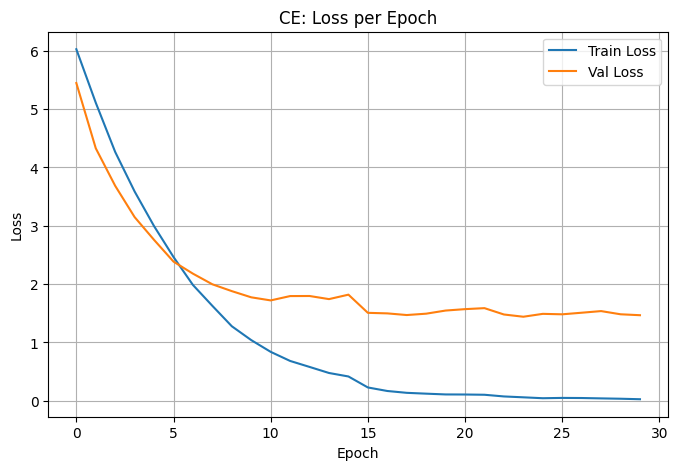

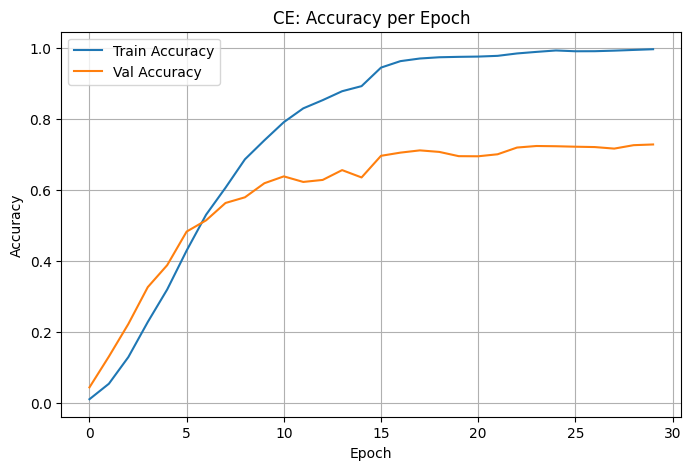

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_ce, label='Train Loss')
plt.plot(val_losses_ce, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("CE: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_ce, label='Train Accuracy')
plt.plot(val_accs_ce, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("CE: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


Train Loss и  уверенно и монотонно убывает. Val Loss также существенно снижается до 10 эпохи, после чего стабилизируется в диапазоне 1.5. После 16 эпохи Train Loss продолжает снижаться, а Val Loss начинает слегка расти, что может говорить о начале переобучения, но при этом Val Accuracy продолжает улучшаться.

Train Accuracy растёт до 99.5%, модель полностью обучается на тренировочном наборе. Тем временем Val Accuracy достигает 72.77% на последней эпохе.

#ArcFace

$$L_{ArcFace} = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos(\Theta_{y_i} + m)}}{e^{s\ cos(\Theta_{y_i} + m)} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$

- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети;  
- $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $\Theta_{y_i}$  — угол между векторами $W_{y_i}$ и $x_i$;
- $m$ — коэффициент углового смещения;
- $s$ — коэффициент масштабирования;
- $N$ — batch size;
- $n$ — количество классов.

В отличие от CrossEntropy, которая оперирует логитами $W_{y}^{T}x$, ArcFace использует косинус угла между эмбеддингом и весом класса.

Для этого эмбеддинги и веса нормализуются, при этом нормализованные эмбеддинги домножаются на гиперпараметр $s$. И теперь результат $sW_{y}^{T}x$ можно переписать как $s\cos\Theta_{y}$.  

Для истинного класса угол увеличивается на фиксированное угловое смещение $m$ → $cos(\Theta_{y_i}+m)$. Это усиливает отдаленность различных классов и заставляет эмбеддинги одного класса быть ближе друг к другу (меньше угол), а разных классов — дальше (больше угол). Таким образом создается сферически разделимое пространство признаков.  

Плюсы:
- улучшает разделимость эмбеддингов;
- хорошо работает даже при большом числе классов;
- подходит для идентификации лиц, отсутствующих в обучающей выборке.

Минусы:
- необходим аккуратный подбор гиперпараметров s и m;
- могут возникать проблемы с переобучением при малом количестве примеров на класс.

Возьмем значения гиперпараметров $s = 64$ и $m = 0.5$ из оригинальной статьи: https://arxiv.org/pdf/1801.07698

In [ ]:
import torch.nn.functional as F
import math

class ArcFaceLoss(nn.Module):
    def __init__(self, s=64.0, m=0.5, reduction='mean'):
        super().__init__()
        self.s = s
        self.m = m
        self.reduction = reduction
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, logits, labels):
        cosine = logits
        sine = torch.sqrt(1.0 - torch.clamp(cosine ** 2, 0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).type_as(cosine)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return F.cross_entropy(output, labels, reduction=self.reduction)


Заменим последний слой ResNet50 на Linear → ReLU → Dropout, чтобы получить 256-мерные эмбеддинги. Классификатор в ArcFace - это отдельный слой без bias, применяемый к нормированным эмбеддингам.  

В модели с CrossEntropy классификатор встроен в backbone и сразу выдаёт логиты, а в ArcFace - выносится отдельно, так как логиты вычисляются по косинусной близости.

In [ ]:
backbone = models.resnet50(pretrained=True)
backbone.fc = nn.Sequential(
    nn.Linear(backbone.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3)
)

num_classes = len(train_dataset.classes)
classifier = nn.Linear(256, num_classes, bias=False)

criterion = ArcFaceLoss(s=64.0, m=0.5)

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(classifier.parameters()), lr=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
    threshold=1e-4, verbose=True
)


backbone = backbone.to(device)
classifier = classifier.to(device)


In [ ]:
def train_arcface_classifier(
    model, classifier,
    train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=10, device='cuda',
    save_path='best_checkpoint_arcface.pth'
):
    model.to(device)
    classifier.to(device)
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    best_classifier_wts = copy.deepcopy(classifier.state_dict())

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        classifier.train()
        train_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            features = model(images)
            features = F.normalize(features)
            weights = F.normalize(classifier.weight, dim=1)
            logits = features @ weights.T

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = logits.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = train_loss / total
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        print(f"Train Loss: {epoch_train_loss:.4f}, Accuracy: {epoch_train_acc:.4f}")

        model.eval()
        classifier.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                features = model(images)
                features = F.normalize(features)
                weights = F.normalize(classifier.weight, dim=1)
                logits = features @ weights.T

                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = logits.max(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        print(f"Val   Loss: {epoch_val_loss:.4f}, Accuracy: {epoch_val_acc:.4f}")

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_classifier_wts = copy.deepcopy(classifier.state_dict())
            print(f"Model saved at epoch {epoch+1} (val_loss={epoch_val_loss:.4f})")

    torch.save({
        'backbone_state': best_model_wts,
        'classifier_state': best_classifier_wts,
        'optimizer_state': optimizer.state_dict(),
        'val_loss': best_val_loss,
        'epoch': epoch + 1,
    }, save_path)

    model.load_state_dict(best_model_wts)
    classifier.load_state_dict(best_classifier_wts)

    return train_losses, val_losses, train_accuracies, val_accuracies


In [ ]:
train_losses_arc, val_losses_arc, train_accs_arc, val_accs_arc = train_arcface_classifier(
    model=backbone,
    classifier=classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=30,
    device=device,
    save_path="resnet_arcface_best.pth"
)

Epoch 1/30 [Train]: 100%|██████████| 376/376 [00:27<00:00, 13.69it/s]

Train Loss: 39.1894, Accuracy: 0.0047


Val   Loss: 36.3432, Accuracy: 0.0376
Model saved at epoch 1 (val_loss=36.3432)


Epoch 2/30 [Train]: 100%|██████████| 376/376 [00:26<00:00, 14.04it/s]

Train Loss: 37.2511, Accuracy: 0.0317


...

Train Loss: 6.3326, Accuracy: 0.9406


Val   Loss: 16.6032, Accuracy: 0.7191


Epoch 30/30 [Train]: 100%|██████████| 376/376 [00:26<00:00, 13.96it/s]

Train Loss: 5.8062, Accuracy: 0.9470


Val   Loss: 16.3640, Accuracy: 0.7267


И тоже вглянем на графики:

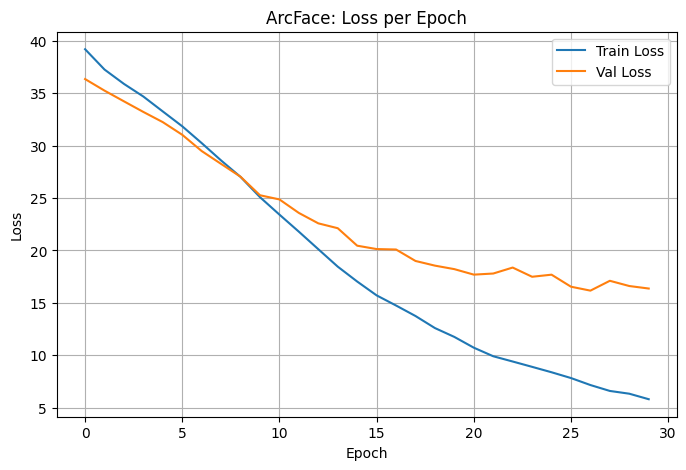

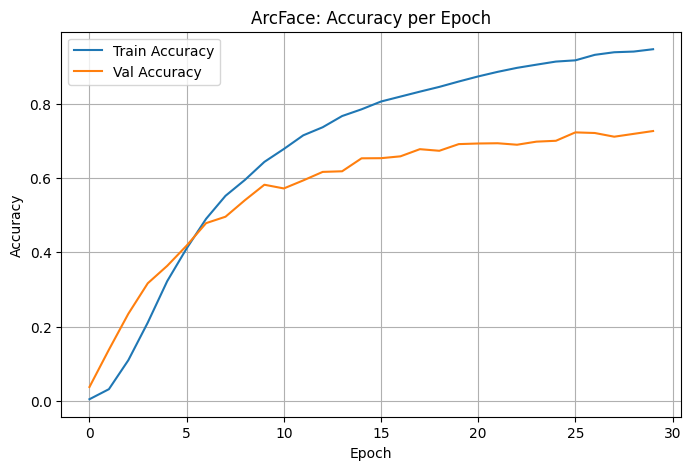

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_arc, label='Train Loss')
plt.plot(val_losses_arc, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("ArcFace: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_arc, label='Train Accuracy')
plt.plot(val_accs_arc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("ArcFace: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Также как и в предыдущем случае, Train Loss за 30 эпох уверенно снижается, Val Loss также последовательно убывает. Минимум достигается на 27-й эпохе.Абсолютные значения loss велики, но для ArcFace при s=64.0 это нормально.  

Train Accuracy растёт до 94.7%, модель хорошо учится на тренировочных данных. Val Accuracy растёт до 72.67%, что сравнимо с результатами модели на CrossEntropy, но достигается за счёт более структурированных эмбеддингов.

Наилучшая валидационная точность достигается к концу обучения.

Сравним графики CE и ArcFace

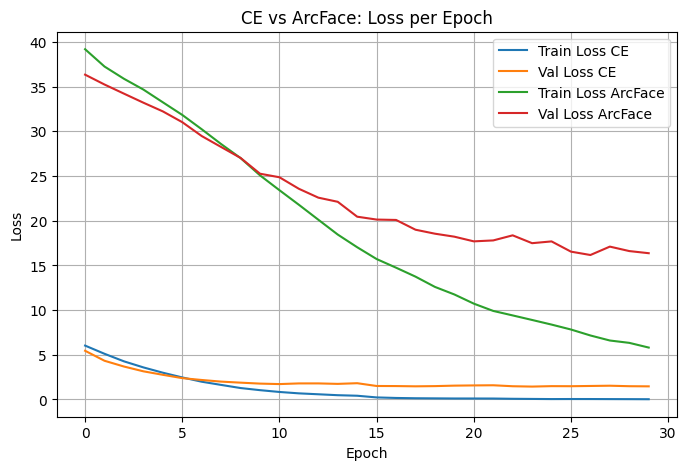

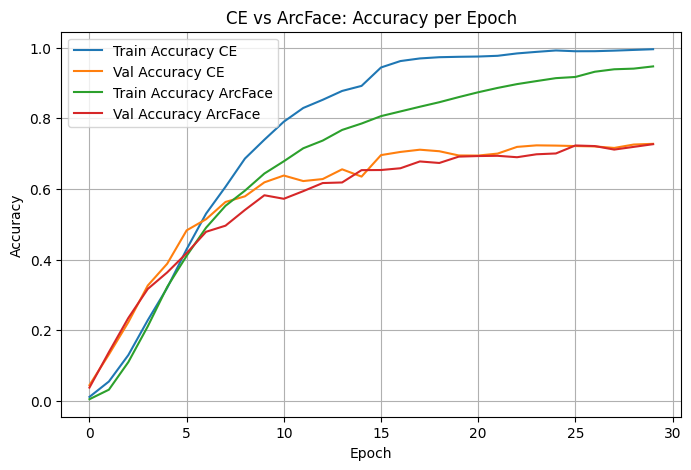

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_ce, label='Train Loss CE')
plt.plot(val_losses_ce, label='Val Loss CE')
plt.plot(train_losses_arc, label='Train Loss ArcFace')
plt.plot(val_losses_arc, label='Val Loss ArcFace')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("CE vs ArcFace: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_ce, label='Train Accuracy CE')
plt.plot(val_accs_ce, label='Val Accuracy CE')
plt.plot(train_accs_arc, label='Train Accuracy ArcFace')
plt.plot(val_accs_arc, label='Val Accuracy ArcFace')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("CE vs ArcFace: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


Что видим: CE обучается быстрее и достигает почти 100% уже к 25-й эпохе, в то время как ArcFace обучается плавнее и медленнее, не доходя до 95%. Что же касается Val Accuracy, то здесь CE немного опережает ArcFace (на 0.1%).

Loss CE значительно меньше по шкале, и это связано s = 64 у ArcFace. Можно заметить колебания Val Loss у ArcFace, но они не сопровождаются резким ростом или деградацией, а точность продолжает расти. То есть несмотря на шум обучение остается устойчивым

Обе модели демонстрируют хорошую сходимость, но у CE чуть выраженнее переобучение после 15-й эпохи.

#TripletLoss

$$
\mathcal{L}_{\text{Triplet}} = \frac{1}{N} \sum_{i=1}^{N} \left[ \| f(x_i^a) - f(x_i^p) \|_2^2 - \| f(x_i^a) - f(x_i^n) \|_2^2 + \alpha \right]_+
$$
- $f(x)$ — эмбеддинг входного лица (output модели);
- $x_i^a$ — "anchor" пример;
- $x_i^p$ — "positive" пример (та же identity);
- $x_i^n$ — "negative" пример (другая identity);
- $\alpha$ — зазор между положительной $(x_i^a; x_i^p)$ и отрицательной $(x_i^a; x_i^n)$ парами;
- $N$ — batch size.

В отличие от CrossEntropy и ArcFace, Triplet Loss не требует фиксированного количества классов. Он оперирует расстояниями между эмбеддингами: модель учится сжимать расстояние между anchor и positive, одновременно увеличивая расстояние между anchor и negative хотя бы на величину margin.

Мы используем Triplet Loss для того, чтобы эмбеддинги напрямую отражали сходство между лицами: чем ближе эмбеддинги, тем выше вероятность, что изображения принадлежат одной и той же identity.

**Плюсы:**
- не требует явно заданного числа классов (может обучаться на произвольных identities);
- хорошо обобщается на новые, ранее не встречавшиеся лица.

**Минусы:**
- требует аккуратного подбора триплетов (плохая выборка делает обучение невозможным);
- медленно обучается, сложнее в реализации.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TripletLoss(nn.Module):
    def __init__(self, margin=0.3, p=2, reduction='mean'):
        super().__init__()
        self.margin = margin
        self.p = p
        self.reduction = reduction

    def forward(self, anchor, positive, negative):
        d_ap = F.pairwise_distance(anchor, positive, p=self.p)
        d_an = F.pairwise_distance(anchor, negative, p=self.p)

        losses = F.relu(d_ap - d_an + self.margin)

        if self.reduction == 'mean':
            return losses.mean()
        elif self.reduction == 'sum':
            return losses.sum()
        else:
            return losses

В качестве модели возьмем модифицированный ResNet50, предназначенный для извлечения эмбеддингов.  

Для этого удалим последний классификационный слой, вместо него добавим Linear-слой, понижающий размерность выходного вектора до 256, и нормализуем эмбеддинг.

In [ ]:
import torch.nn as nn
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau

class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        base_model = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(base_model.children())[:-1])
        self.embedding = nn.Linear(base_model.fc.in_features, embedding_dim)

    def forward(self, x):
        x = self.backbone(x).squeeze()
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

Создадим функцию для оценки качества модели, обученной с Triplet Loss.  


Она вычисляет долю триплетов, в которых расстояние между anchor и positive меньше, чем между anchor и negative хотя бы на заданную величину margin. Чем выше значение, тем лучше модель различает похожие и разные пары.

In [ ]:
import torch.nn.functional as F
from torch import nn, optim

def compute_triplet_accuracy(anchor, positive, negative, margin=0.3):
    d_ap = torch.norm(anchor - positive, dim=1)
    d_an = torch.norm(anchor - negative, dim=1)
    return ((d_ap + margin) < d_an).float().mean().item()


In [ ]:
def train_triplet_model(
    model,
    train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=10, device='cuda',
    save_path='best_checkpoint_triplet.pth'
):
    import copy
    model.to(device)
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_acc, total_train = 0.0, 0.0, 0

        for a, p, n in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            a, p, n = a.to(device), p.to(device), n.to(device)
            batch_size = a.size(0)

            anchor = model(a)
            positive = model(p)
            negative = model(n)

            loss = criterion(anchor, positive, negative)
            acc = compute_triplet_accuracy(anchor, positive, negative)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_size
            train_acc += acc * batch_size
            total_train += batch_size

        epoch_train_loss = train_loss / total_train
        epoch_train_acc = train_acc / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        print(f"Train Loss: {epoch_train_loss:.4f}, Triplet Train Acc: {epoch_train_acc:.4f}")

        model.eval()
        val_loss, val_acc, total_val = 0.0, 0.0, 0
        with torch.no_grad():
            for a, p, n in val_loader:
                a, p, n = a.to(device), p.to(device), n.to(device)
                batch_size = a.size(0)

                anchor = model(a)
                positive = model(p)
                negative = model(n)

                loss = criterion(anchor, positive, negative)
                acc = compute_triplet_accuracy(anchor, positive, negative)

                val_loss += loss.item() * batch_size
                val_acc += acc * batch_size
                total_val += batch_size

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_acc / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        print(f"Val Loss: {epoch_val_loss:.4f}, Triplet Val Acc: {epoch_val_acc:.4f}")

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"Model saved at epoch {epoch+1} (val_loss={epoch_val_loss:.4f})")

    torch.save({
        'model_state': best_model_wts,
        'optimizer_state': optimizer.state_dict(),
        'val_loss': best_val_loss,
        'epoch': epoch + 1,
    }, save_path)

    model.load_state_dict(best_model_wts)

    return train_losses, val_losses, train_accuracies, val_accuracies


Используем специально созданные для TripletLoss Dataloader'ы.

In [ ]:
model = EmbeddingNet(embedding_dim=256).to(device)
criterion = TripletLoss(margin=0.3, p=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

train_losses_tri, val_losses_tri, train_accs_tri, val_accs_tri = train_triplet_model(
    model,
    train_loader=train_loader_triplet,
    val_loader=val_loader_triplet,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=30,
    device=device,
    save_path="best_triplet_model.pth"
)


Epoch 1/30 [Train]: 100%|██████████| 376/376 [01:16<00:00,  4.94it/s]

Train Loss: 0.1118, Triplet Train Acc: 0.6806


Val Loss: 0.1006, Triplet Val Acc: 0.7390
Model saved at epoch 1 (val_loss=0.1006)


Epoch 2/30 [Train]: 100%|██████████| 376/376 [01:15<00:00,  4.95it/s]

Train Loss: 0.0792, Triplet Train Acc: 0.7800


...

Train Loss: 0.0052, Triplet Train Acc: 0.9803


Val Loss: 0.0462, Triplet Val Acc: 0.8664


Epoch 30/30 [Train]: 100%|██████████| 376/376 [01:15<00:00,  4.95it/s]

Train Loss: 0.0046, Triplet Train Acc: 0.9822


Val Loss: 0.0457, Triplet Val Acc: 0.8723


Accuracy - огонь! Смотрим графики:

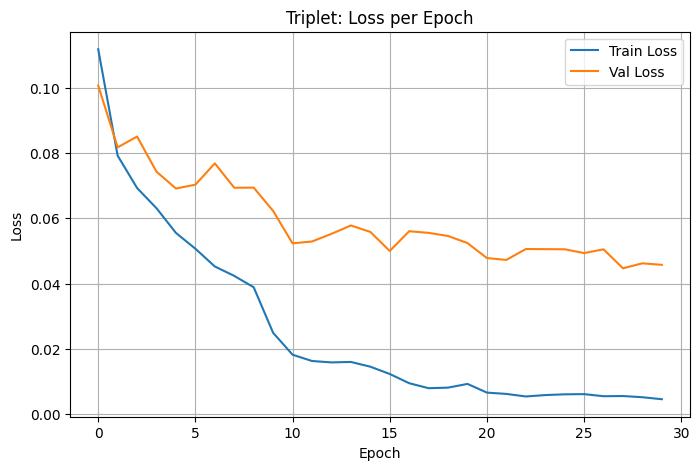

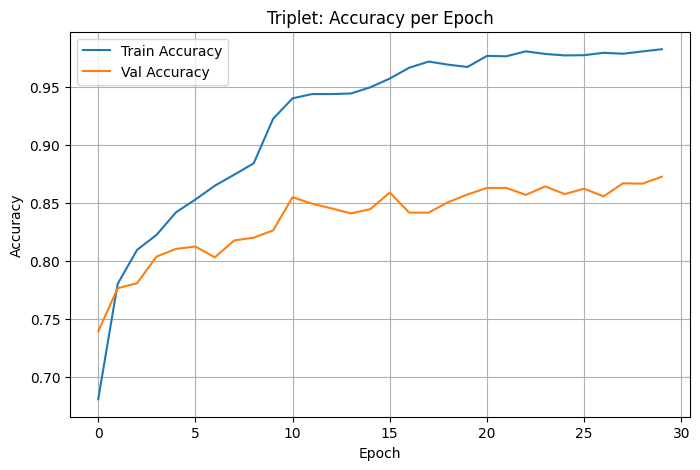

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_tri, label='Train Loss')
plt.plot(val_losses_tri, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Triplet: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_tri, label='Train Accuracy')
plt.plot(val_accs_tri, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Triplet: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


Train Accuracy на старте была уже более 68% и выросла до 98.2% к концу обучения. Val Accuracy устойчиво улучшалась до 87.2%.
Модель быстро и успешно обучилась различать положительные и отрицательные пары.  

Train Loss быстро убывает с 0.11 до 0.005. Val Loss также снижается до 0.0447, признаков переобучения нет. Минимальный val_loss достигнут на 28 эпохе.

Шум есть, но на фоне росте accuracy и снижении loss он не критичен.

Посмотрим на все вышеприведенные графики разом:

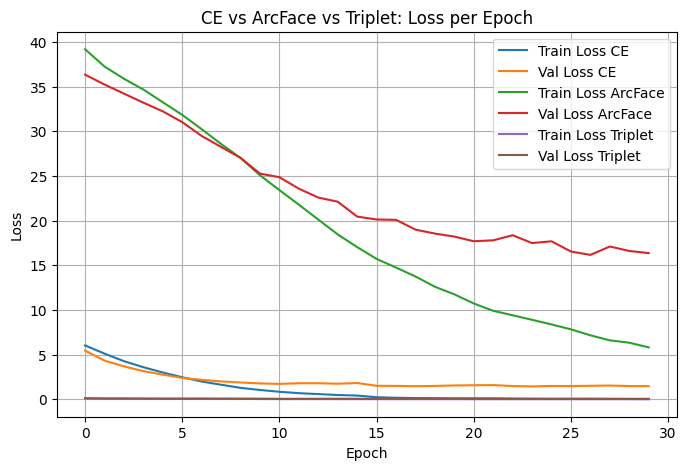

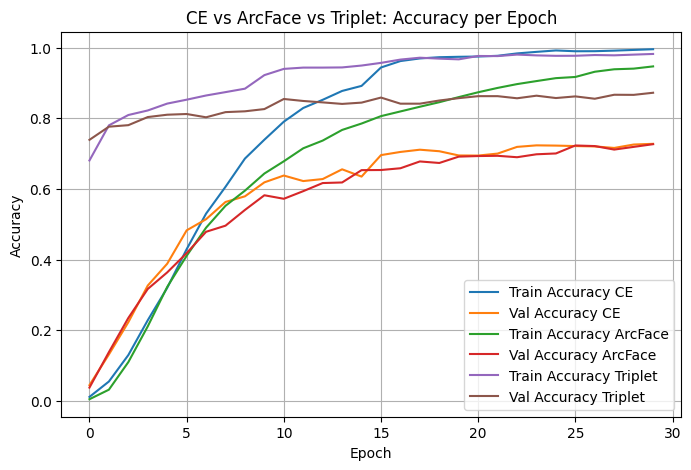

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_ce, label='Train Loss CE')
plt.plot(val_losses_ce, label='Val Loss CE')
plt.plot(train_losses_arc, label='Train Loss ArcFace')
plt.plot(val_losses_arc, label='Val Loss ArcFace')
plt.plot(train_losses_tri, label='Train Loss Triplet')
plt.plot(val_losses_tri, label='Val Loss Triplet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("CE vs ArcFace vs Triplet: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_ce, label='Train Accuracy CE')
plt.plot(val_accs_ce, label='Val Accuracy CE')
plt.plot(train_accs_arc, label='Train Accuracy ArcFace')
plt.plot(val_accs_arc, label='Val Accuracy ArcFace')
plt.plot(train_accs_tri, label='Train Accuracy Triplet')
plt.plot(val_accs_tri, label='Val Accuracy Triplet')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("CE vs ArcFace vs Triplet: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Triplet Loss самый низкий по шкале, ArcFace Loss - самый высокий. Оба уверенно снижаются. CE Loss быстро убывает, но валидационная часть слишком рано стабилизируется, что указывает на лёгкое переобучение к 30 эпохе.

Triplet показывает наилучшую Accuracy (87%) и превосходит CE и ArcFace уже с 5 эпохи.
CE и ArcFace удивительно синхронны, достигают 72–73% val accuracy.
Train Accuracy выше у CE (до 99.5%), Triplet на втором месте. Но у последнего есть выигрыш по обобщающей способности.  

Все модели весьма неплохо себя показали, но Triplet Loss - фаворит.

##Смешанные лоссы

#CrossEntropy + ArcFace

При использовании ArcFace модель должна не просто правильно классифицировать,но ещё и отодвигать сдвигать одного класса ближе друг к другу, и раздвигать от других. В начале обучения это может ухудшать сходимость (loss может "прыгать" или застывать).

CrossEntropy работает без углового смещения, она просто увеличивает логит правильного класса сильнее, чем остальных. В теории добавление ее ускорит сходимость в начале обучения и поможет эмбеддингам начать формироваться в нужном направлении. То есть CE играет роль "стабилизатора":
она делает задачу чуть проще в начале, пока модель учится хоть как-то различать классы.

$$
\mathcal{L} = \mathcal{L}_{\text{ArcFace}}+\lambda \cdot \mathcal{L}_{\text{CE}}$$  
- $\lambda$ — вес CE-компоненты. Возьмем его равным 0.2

In [ ]:
class ArcFaceCELoss(nn.Module):
    def __init__(self, s=64.0, m=0.5, ce_weight=0.2, reduction='mean'):
        super().__init__()
        self.s = s
        self.m = m
        self.ce_weight = ce_weight
        self.reduction = reduction
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, cosine, labels):
        sine = torch.sqrt(1.0 - torch.clamp(cosine ** 2, 0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).type_as(cosine)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output_arc = output * self.s
        output_ce = cosine * self.s

        loss_arc = F.cross_entropy(output_arc, labels, reduction=self.reduction)
        loss_ce  = F.cross_entropy(output_ce, labels, reduction=self.reduction)

        return loss_arc + self.ce_weight * loss_ce


backbone точно такой же, как в ArcFace

In [ ]:
backbone = models.resnet50(pretrained=True)
backbone.fc = nn.Sequential(
    nn.Linear(backbone.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3)
)

num_classes = len(train_dataset.classes)
classifier = nn.Linear(256, num_classes, bias=False)

criterion = ArcFaceCELoss(s=64.0, m=0.5, ce_weight=0.2)

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(classifier.parameters()), lr=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
    threshold=1e-4, verbose=True
)


backbone = backbone.to(device)
classifier = classifier.to(device)


In [ ]:
train_losses_arce, val_losses_arce, train_accs_arce, val_accs_arce = train_arcface_classifier(
    model=backbone,
    classifier=classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=30,
    device=device,
    save_path="resnet_arcface_ce.pth"
)

Epoch 1/30 [Train]: 100%|██████████| 376/376 [00:27<00:00, 13.70it/s]

Train Loss: 40.9226, Accuracy: 0.0047


Val   Loss: 37.3356, Accuracy: 0.0519
Model saved at epoch 1 (val_loss=37.3356)


Epoch 2/30 [Train]: 100%|██████████| 376/376 [00:27<00:00, 13.72it/s]

Train Loss: 38.7360, Accuracy: 0.0270


...

Train Loss: 4.5460, Accuracy: 0.9721


Val   Loss: 17.7183, Accuracy: 0.7171


Epoch 30/30 [Train]: 100%|██████████| 376/376 [00:26<00:00, 13.96it/s]

Train Loss: 4.4926, Accuracy: 0.9706


Val   Loss: 17.2196, Accuracy: 0.7307


Смотрим

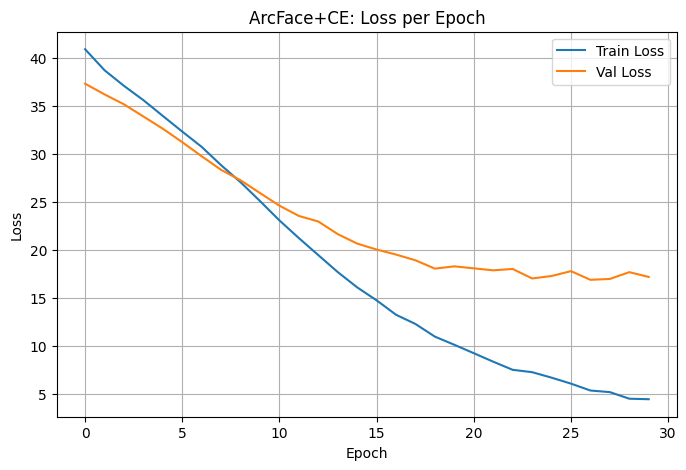

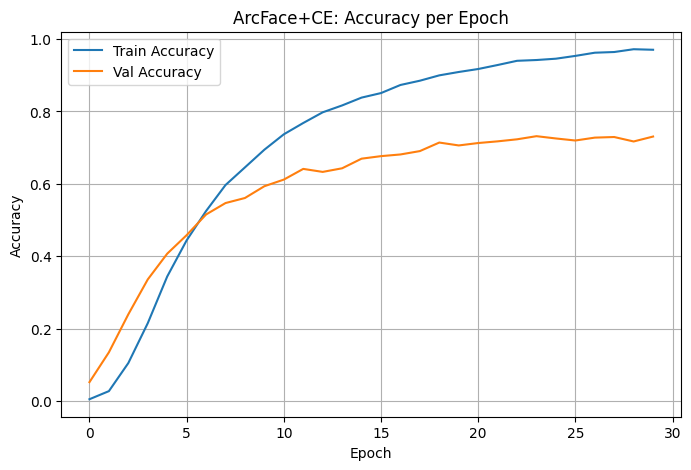

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_arce, label='Train Loss')
plt.plot(val_losses_arce, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("ArcFace+CE: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_arce, label='Train Accuracy')
plt.plot(val_accs_arce, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("ArcFace+CE: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


Train Accuracy достигает 0.97 к 30 эпохе, то есть сходимость отличная. Val Accuracy стабилизируется в районе 0.73, и это выше, чем у CE и ArcFace по отдельности. Loss-кривые падают монотонно, явного переобучения нет.

Посмотрим на все три модели: и CE, и ArcFace, и гибрид:

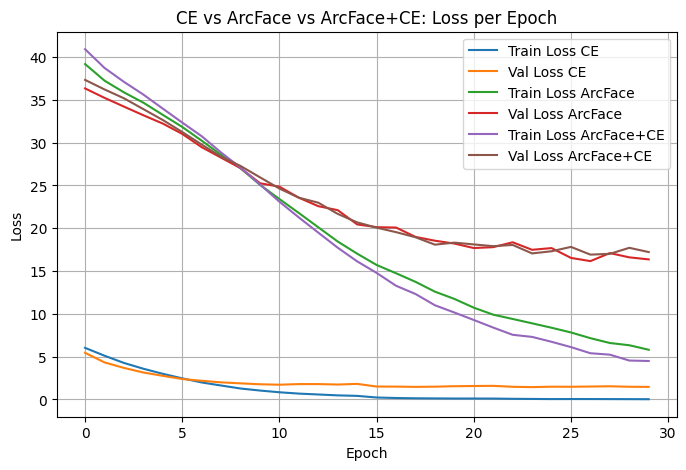

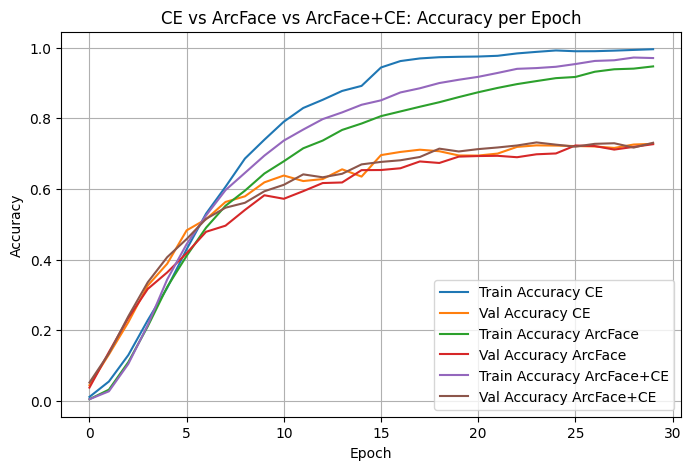

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_ce, label='Train Loss CE')
plt.plot(val_losses_ce, label='Val Loss CE')
plt.plot(train_losses_arc, label='Train Loss ArcFace')
plt.plot(val_losses_arc, label='Val Loss ArcFace')
plt.plot(train_losses_arce, label='Train Loss ArcFace+CE')
plt.plot(val_losses_arce, label='Val Loss ArcFace+CE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("CE vs ArcFace vs ArcFace+CE: Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_ce, label='Train Accuracy CE')
plt.plot(val_accs_ce, label='Val Accuracy CE')
plt.plot(train_accs_arc, label='Train Accuracy ArcFace')
plt.plot(val_accs_arc, label='Val Accuracy ArcFace')
plt.plot(train_accs_arce, label='Train Accuracy ArcFace+CE')
plt.plot(val_accs_arce, label='Val Accuracy ArcFace+CE')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("CE vs ArcFace vs ArcFace+CE: Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Train Accuracy и Val Accuracy у ArcFace + CE выше, чем у ArcFace и плавнее, чем у CE. При этом Val Accuracy стабильно растёт и выходит на уровень 73%+, что выше, чем у CE и ArcFace. Обучение идёт гладко: без резких скачков и провалов, что говорит о хорошей устойчивости оптимизации.

Гибрид демонстрирует наиболее сбалансированное поведение:
быстрее сходится, показывает более высокое качество на валидации, не переобучается.

#ArcFace+Triplet

Тут мы решились на отчаянный эксперимент: триплеты формируются динамически внутри каждого батча.  
Для каждого изображения подбираются:
- положительный пример из того же класса, отличный от самого anchor;
- отрицательный пример из любого другого класса.

Реализуем модель, обучаемую с использованием смешанного лосса, объединяющего преимущества ArcFace Loss и Triplet Loss. Был реализован комбинированный лосс ArcFaceTripletLoss, вычисляющий сумму двух составляющих:
- ArcFace Loss отвечает за классификацию и повышение межклассового углового различия;
- Triplet Loss оптимизирует эмбеддинги, сближая положительные пары и отдаляя отрицательные.

$$
\mathcal{L} = \alpha \cdot \mathcal{L}_{\text{ArcFace}}+\beta \cdot \mathcal{L}_{\text{Triplet}}$$  

Параметры $\alpha$ и $\beta$ управляют вкладом каждой из компонент.


В качестве метрики качества используем среднее гармоническое обеих Accuracy c поправкой на веса:

$$\text{TotalAcc} = \frac{2 \cdot \alpha \cdot \beta \cdot \text{ArcAcc} \cdot \text{TripletAcc}}{\alpha \cdot \text{ArcAcc} + \beta \cdot \text{TripletAcc} + \varepsilon}$$


Backbone используем, как для ArcFace

In [ ]:
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

backbone = models.resnet50(pretrained=True)
backbone.fc = nn.Sequential(
    nn.Linear(backbone.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3)
)

num_classes = len(train_dataset.classes)

classifier = nn.Linear(256, num_classes, bias=False)


In [ ]:
class ArcFaceTripletLoss(nn.Module):
    def __init__(self, arcface_loss, triplet_loss, alpha=1.0, beta=1.0):
        super().__init__()
        self.arcface_loss = arcface_loss
        self.triplet_loss = triplet_loss
        self.alpha = alpha
        self.beta = beta

    def forward(self, features, logits, labels, anchor, positive, negative):
        loss_arc = self.arcface_loss(logits, labels)
        loss_triplet = self.triplet_loss(anchor, positive, negative)
        return self.alpha * loss_arc + self.beta * loss_triplet


In [ ]:
import random
from collections import defaultdict

def get_triplets(images, labels):
    """
    Формирует триплеты (anchor, positive, negative) внутри одного батча.
    images: Tensor размера [B, C, H, W]
    labels: Tensor размера [B]
    Возвращает: anchor, positive, negative — тензоры одной размерности [N, C, H, W]
    """
    label_to_indices = defaultdict(list)
    for idx, label in enumerate(labels):
        label_to_indices[label.item()].append(idx)

    triplets = []
    labels_np = labels.cpu().numpy()
    for anchor_idx in range(len(images)):
        anchor_label = labels[anchor_idx].item()
        anchor = images[anchor_idx]

        positive_candidates = label_to_indices[anchor_label]
        if len(positive_candidates) < 2:
            continue
        positive_idx = anchor_idx
        while positive_idx == anchor_idx:
            positive_idx = random.choice(positive_candidates)
        positive = images[positive_idx]

        negative_label = random.choice([l for l in label_to_indices if l != anchor_label])
        negative_idx = random.choice(label_to_indices[negative_label])
        negative = images[negative_idx]

        triplets.append((anchor, positive, negative))

    anchor_batch, positive_batch, negative_batch = zip(*triplets)
    return torch.stack(anchor_batch), torch.stack(positive_batch), torch.stack(negative_batch)


In [ ]:
def train_arcface_triplet_classifier(
    model, classifier,
    train_loader, val_loader,
    combined_loss, optimizer, scheduler,
    epochs=10, device='cuda',
    save_path='best_checkpoint_arcface_triplet.pth',
    alpha=1.0, beta=1.0
):
    import copy
    import torch.nn.functional as F
    from tqdm import tqdm

    model.to(device)
    classifier.to(device)

    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    best_classifier_wts = copy.deepcopy(classifier.state_dict())

    train_losses, val_losses = [], []
    train_total_accs, val_total_accs = [], []

    for epoch in range(epochs):
        model.train()
        classifier.train()
        train_loss, arc_correct, total_arc, triplet_acc_total = 0.0, 0, 0, 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            embeddings = model(images)
            embeddings = F.normalize(embeddings, dim=1)
            weights = F.normalize(classifier.weight, dim=1)
            logits = embeddings @ weights.T
            anchors, positives, negatives = get_triplets(embeddings, labels)
            if anchors is None:
                continue

            loss = combined_loss(
                embeddings, logits, labels,
                anchors, positives, negatives
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = logits.max(1)
            arc_correct += (preds == labels).sum().item()
            total_arc += labels.size(0)
            triplet_acc_total += compute_triplet_accuracy(anchors, positives, negatives) * anchors.size(0)

        epoch_train_loss = train_loss / total_arc
        arc_acc = arc_correct / total_arc
        triplet_acc = triplet_acc_total / total_arc
        total_acc = 2 * alpha * beta * arc_acc * triplet_acc / (alpha * arc_acc + beta * triplet_acc + 1e-8)
        train_losses.append(epoch_train_loss)
        train_total_accs.append(total_acc)
        print()
        print(f"Train Loss: {epoch_train_loss:.4f}, Total Acc: {total_acc:.4f}, ArcFace Acc: {arc_acc:.4f}, Triplet Acc: {triplet_acc:.4f}")

        model.eval()
        classifier.eval()
        val_loss, val_arc_correct, val_total, val_triplet_acc = 0.0, 0, 0, 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                embeddings = model(images)
                embeddings = F.normalize(embeddings, dim=1)
                weights = F.normalize(classifier.weight, dim=1)
                logits = embeddings @ weights.T

                anchors, positives, negatives = get_triplets(embeddings, labels)
                loss = combined_loss(
                    embeddings, logits, labels,
                    anchors, positives, negatives
                )
                val_loss += loss.item() * images.size(0)
                _, preds = logits.max(1)
                val_arc_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                val_triplet_acc += compute_triplet_accuracy(anchors, positives, negatives) * anchors.size(0)

        epoch_val_loss = val_loss / val_total
        val_arc_acc = val_arc_correct / val_total
        val_triplet_acc = val_triplet_acc / val_total
        val_total_acc = 2 * alpha * beta * val_arc_acc * val_triplet_acc / (alpha * val_arc_acc + beta * val_triplet_acc + 1e-8)
        val_losses.append(epoch_val_loss)
        val_total_accs.append(val_total_acc)
        print(f"Val   Loss: {epoch_val_loss:.4f}, Total Acc: {val_total_acc:.4f}, ArcFace Acc: {val_arc_acc:.4f}, Triplet Acc: {val_triplet_acc:.4f}")

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_classifier_wts = copy.deepcopy(classifier.state_dict())
            print(f"Model saved at epoch {epoch+1} (val_loss={epoch_val_loss:.4f})")

    torch.save({
        'backbone_state': best_model_wts,
        'classifier_state': best_classifier_wts,
        'optimizer_state': optimizer.state_dict(),
        'val_loss': best_val_loss,
        'epoch': epoch + 1,
    }, save_path)

    model.load_state_dict(best_model_wts)
    classifier.load_state_dict(best_classifier_wts)

    return train_losses, val_losses, train_total_accs, val_total_accs


Здесь возьмем одинаковые $\alpha$ и $\beta$. И вдвое бельшее число эпох.

In [ ]:
arcface_loss = ArcFaceLoss(s=64.0, m=0.5)
triplet_loss = TripletLoss(margin=0.3)
combined_loss = ArcFaceTripletLoss(arcface_loss, triplet_loss, alpha=1.0, beta=1.0)

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(classifier.parameters()), lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, threshold=1e-4, verbose=True
)

train_losses_arc1trip1, val_losses_arc1trip1, train_accs_arc1trip1, val_accs_arc1trip1 = train_arcface_triplet_classifier(
    model=backbone,
    classifier=classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    combined_loss=combined_loss,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=60,
    device='cuda',
    save_path='best_arcface1_triplet1.pth'
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/60 [Train]: 100%|██████████| 376/376 [00:22<00:00, 16.64it/s]


Train Loss: 39.9581, Total Acc: 0.0032, ArcFace Acc: 0.0028, Triplet Acc: 0.0039


Val   Loss: 36.9098, Total Acc: 0.0173, ArcFace Acc: 0.0103, Triplet Acc: 0.0535
Model saved at epoch 1 (val_loss=36.9098)


Epoch 2/60 [Train]: 100%|██████████| 376/376 [00:20<00:00, 18.34it/s]


Train Loss: 38.3031, Total Acc: 0.0069, ArcFace Acc: 0.0092, Triplet Acc: 0.0055


...


Train Loss: 2.6644, Total Acc: 0.1726, ArcFace Acc: 0.9872, Triplet Acc: 0.0946


Val   Loss: 14.0321, Total Acc: 0.7347, ArcFace Acc: 0.7653, Triplet Acc: 0.7064


Epoch 60/60 [Train]: 100%|██████████| 376/376 [00:21<00:00, 17.90it/s]


Train Loss: 2.3210, Total Acc: 0.1586, ArcFace Acc: 0.9899, Triplet Acc: 0.0862


Val   Loss: 13.5673, Total Acc: 0.7437, ArcFace Acc: 0.7739, Triplet Acc: 0.7158
Model saved at epoch 60 (val_loss=13.5673)


Подозрительно низкая Accuracy на Train. Смотрим:

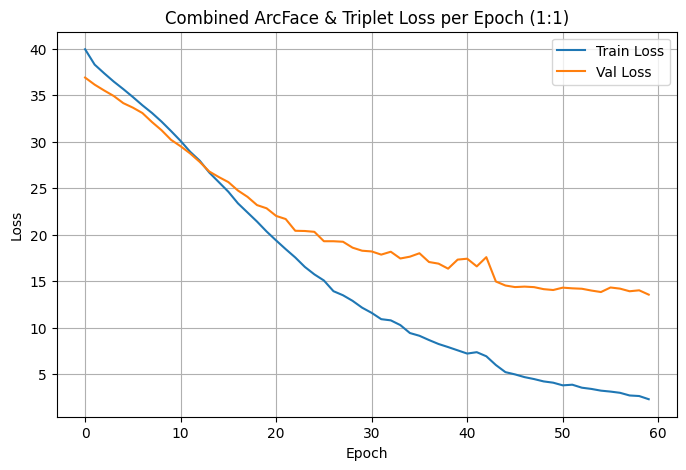

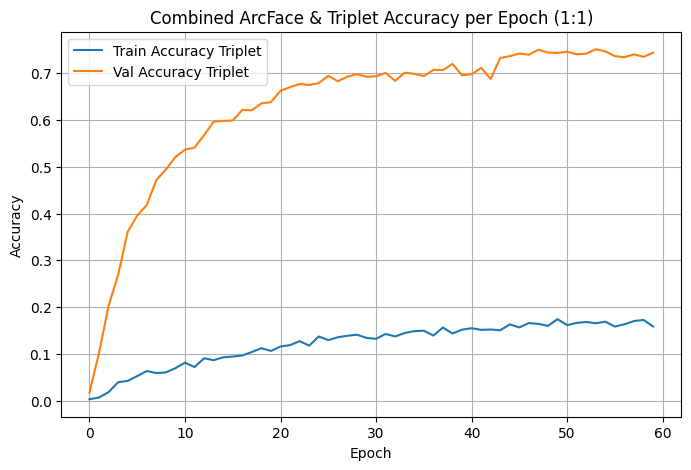

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_arc1trip1, label='Train Loss')
plt.plot(val_losses_arc1trip1, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Combined ArcFace & Triplet Loss per Epoch (1:1)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_arc1trip1, label='Train Accuracy Triplet')
plt.plot(val_accs_arc1trip1, label='Val Accuracy Triplet')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Combined ArcFace & Triplet Accuracy per Epoch (1:1)")
plt.legend()
plt.grid(True)
plt.show()

Train Loss и Val Loss плавно убывают, что является признаком устойчивого обучения и хорошей сходимости. Разрыв между Train и Val Loss небольшой,переобучения почти нет.  

Ситуация с Accuracy интересней. По сути мы используем две Accuracy, итоговая считается как среднее гармоническое. Именно итоговую мы видим на графике, с 44 эпохи она достигла значений 0.74+ и закрепилась на них.

Посмотрим на ее компоненты.  
Triplet Accuracy растёт быстрее: с 0.05 до 0.6 буквально за первые 10 эпох. Дальше этот рост замедляется - метрика выходит на плато в районе 0.72.

В то же время ArcFace Accuracy растёт медленнее, но стабильнее. Она достигает тех же 0.70 только после 40 эпох, зато продолжает расти даже тогда, когда Triplet уже почти не меняется.

Теперь про Train Accuracy. Итоговая Total Accuracy оставалась довольно низкой (всего 0.15–0.17). Вопросов у меня к ней было много, особенно после использования в обучении одиночного Triplet Loss с его 0.87. Потом дошло: раньше модель обучалась на заранее сформированном триплет-датасете, а здесь триплеты формируются "на лету" из текущего батча, где классов меньше и выборка хуже сбалансирована. Это делает Triplet Accuracy на обучении заниженной и не совсем репрезентативной.

Зато на валидации обе метрики растут гармонично, и итоговая Total Accuracy достигает 0.74 к 60 эпохе - это высокий и сбалансированный результат для гибридной модели



ArcFace Acc продолжает расти после того, как Triplet Acc вышла на плато. Попробуем усилить ArcFace: выберем теперь $\alpha = 2$

In [ ]:
arcface_loss = ArcFaceLoss(s=64.0, m=0.5)
triplet_loss = TripletLoss(margin=0.3)
combined_loss = ArcFaceTripletLoss(arcface_loss, triplet_loss, alpha=2.0, beta=1.0)

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(classifier.parameters()), lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, threshold=1e-4, verbose=True
)

train_losses_arc2trip1, val_losses_arc2trip1, train_accs_arc2trip1, val_accs_arc2trip1 = train_arcface_triplet_classifier(
    model=backbone,
    classifier=classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    combined_loss=combined_loss,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=60,
    device='cuda',
    save_path='best_arcface1_triplet1.pth'
)

Epoch 1/60 [Train]: 100%|██████████| 376/376 [00:21<00:00, 17.57it/s]


Train Loss: 79.6388, Total Acc: 0.0037, ArcFace Acc: 0.0041, Triplet Acc: 0.0033


Val   Loss: 73.5568, Total Acc: 0.0311, ArcFace Acc: 0.0223, Triplet Acc: 0.0515
Model saved at epoch 1 (val_loss=73.5568)


Epoch 2/60 [Train]: 100%|██████████| 376/376 [00:20<00:00, 18.18it/s]


Train Loss: 76.2353, Total Acc: 0.0088, ArcFace Acc: 0.0121, Triplet Acc: 0.0069


...


Train Loss: 4.5066, Total Acc: 0.1600, ArcFace Acc: 0.9879, Triplet Acc: 0.0870


Val   Loss: 27.1351, Total Acc: 0.7390, ArcFace Acc: 0.7699, Triplet Acc: 0.7104
Model saved at epoch 59 (val_loss=27.1351)


Epoch 60/60 [Train]: 100%|██████████| 376/376 [00:21<00:00, 17.75it/s]


Train Loss: 4.2606, Total Acc: 0.1603, ArcFace Acc: 0.9888, Triplet Acc: 0.0872


Val   Loss: 26.9201, Total Acc: 0.7417, ArcFace Acc: 0.7743, Triplet Acc: 0.7118
Model saved at epoch 60 (val_loss=26.9201)


Было долго и страшно, но мы это сделали.  
Triplet Accuracy по-прежнему стартует резче: на валидации за первые 10 эпох с 0.05 до 0.60. ArcFace Accuracy растёт стабильно, но гораздо медленнее, зато продолжает улучшаться до самой последней эпохи. Смотрим графики:

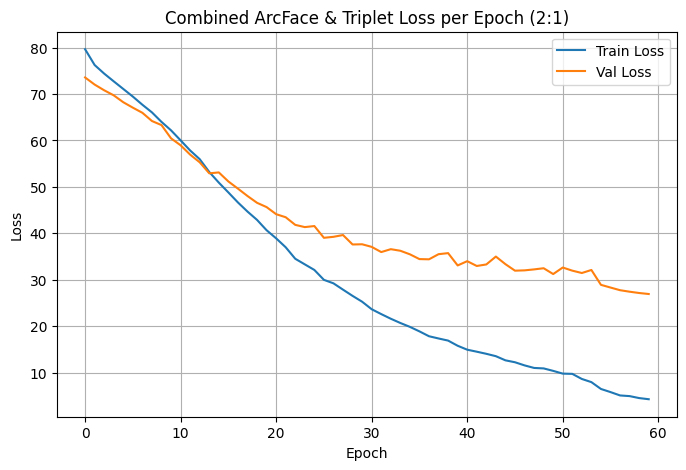

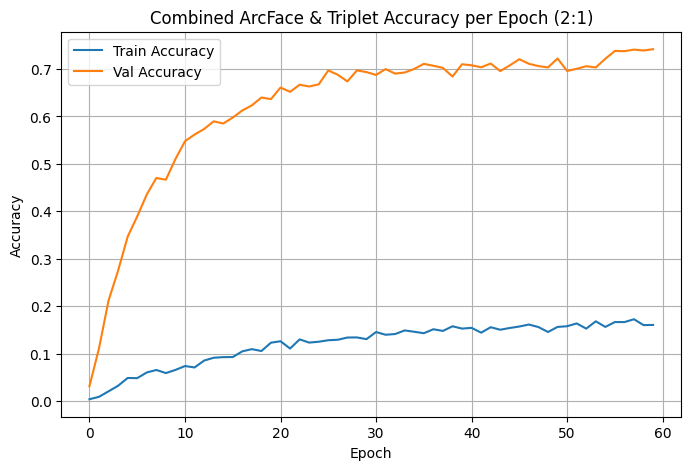

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_arc2trip1, label='Train Loss')
plt.plot(val_losses_arc2trip1, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Combined ArcFace & Triplet Loss per Epoch (2:1)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_arc2trip1, label='Train Accuracy')
plt.plot(val_accs_arc2trip1, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Combined ArcFace & Triplet Accuracy per Epoch (2:1)")
plt.legend()
plt.grid(True)
plt.show()

Сходимость модели все еще хороша, Loss убывает стабильно, хоть и с шумом, но без скачков, модель хорошо обучается, переобучения нет.

Accuracy на валидации растёт быстро и выходит на плато около 0.74. Train Accuracy все так же мала, что ожидаемо, так как триплеты формируются на лету.

Графики похожи на предыдущие, а потому посмотрим на них вместе:



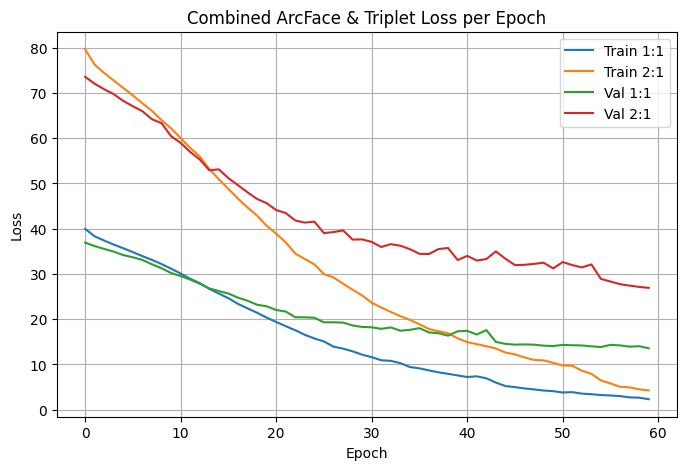

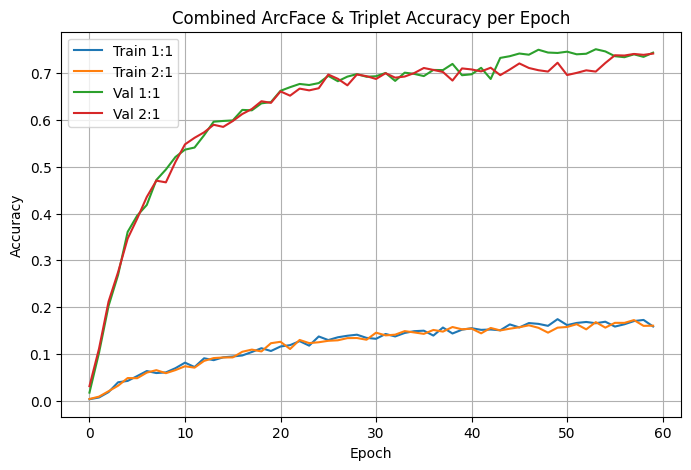

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_arc1trip1, label='Train 1:1')
plt.plot(train_losses_arc2trip1, label='Train 2:1')
plt.plot(val_losses_arc1trip1, label='Val 1:1')
plt.plot(val_losses_arc2trip1, label='Val 2:1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Combined ArcFace & Triplet Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs_arc1trip1, label='Train 1:1')
plt.plot(train_accs_arc2trip1, label='Train 2:1')
plt.plot(val_accs_arc1trip1, label='Val 1:1')
plt.plot(val_accs_arc2trip1, label='Val 2:1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Combined ArcFace & Triplet Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

В обоих режимах обучения Accuracy ведут себя синхронно: на валидации обе модели сходятся к значению около 0.74. Однако есть различие в динамике: при весах 1:1 модель достигает пика 0.75+ уже к 42-43 эпохе, в то время как при 2:1 такой же уровень достигается только к 55 эпохе. Это говорит о более плавной, но устойчивой сходимости модели с увеличенным весом ArcFace.

Что касается loss, то Train и Val Loss при соотношении 2:1 закономерно выше (это ожидаемо, так как ArcFace имеет большую амплитуду значений и усилен в итоговом лоссе). Это увеличение не свидетельствует о деградации качества. Напротив - там, где кривые loss при 1:1 начинают стагнировать (примерно после 35 эпохи), модель с неравными весами продолжает уверенное убывание и на трейне, и на валидации. Это указывает на более глубокую оптимизацию и (в теории) лучшее обобщение в дальнейшем.  

А значит именно ее мы и возьмем для финального прогона.

#Итог:

- **CE** 0.7277;

- **ArcFace** 0.7267.    

- **TripletLoss** 0.8723.

- **CE + ArcFace** 0.7307.

- **ArcFace + Triplet** (1:1) 0.7437.

- **ArcFace + Triplet** (2:1) 0.7417

Теперь посмотрим на наши модели в деле.